I will be using the Califonia Housing dataset. This dataset was obtained from the StatLib repository.
 https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

 The dataset was accessed using the scikit-learn library, which provides a cleaned version of the original StatLib dataset.


The target variable is the median house value for California districts, expressed in hundreds of thousands of dollars ($100,000).

Predicator varbles I chose are:



*   MedInc
*   AveRooms

*   Latitude
*   HouseAge


*   Longitude




I chose these predicators because they are the most importance variables affecting house price in  califonia.











In [ ]:
#loading all the python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#fatching the dataset
from sklearn.datasets import fetch_california_housing

In [ ]:
#loading the califonia Housing  dataset
data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
df.shape


(20640, 9)

The dataset has 20640 rows and 9 columns. Each row represents a district in California. Columns represents housing features such as MedIncome, AveRooms, HousesAge etc.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


RangeIndex:The dataset has 20640 entries numbered from 0 up to 20639 each row is one observation
Data columns: It has 9 column variables describing each observation

In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


There is an outlier in HouseAge, AveOccup, and population because of the large std

columns like the MedInc is fairly balance and others are very skewed.

In [ ]:
df.isnull().sum()


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


No mising values in each column

In [ ]:

df.duplicated().sum()

np.int64(0)

No doublicate rows

In [ ]:
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


MedInc has the highest positive correlation and latitude has the strongest negative correlation.

In [ ]:
df.corr()['MedHouseVal'].sort_values(ascending=False)

,MedHouseVal
MedHouseVal,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


MedInc has the highest positive correlation and latitude has the strongest negative correlation. This shows that Areas with higher income tend to have higher house prices, and houses further north (higher latitude) tend to be cheaper.

At the beginning of the analysis, the dataset was checked for potential issues.

There were no missing values or duplicate records in the dataset.

However, some potential issues were identified:
- Certain variables such as AveOccup showed unusually high values, indicating the presence of possible outliers.
- A high correlation was observed between AveRooms and AveBedrms, suggesting multicollinearity.
- Some variables such as Population showed very weak correlation with the target variable, meaning they may not be useful predictors.

These observations were considered when selecting variables for the model.

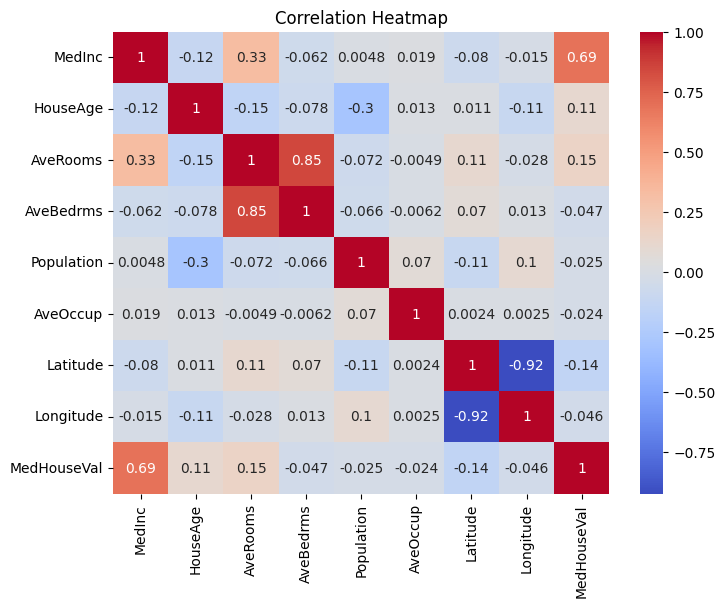

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows the relationships between variables.

Median income (MedInc) has the strongest positive correlation with house value, indicating it is an important predictor.

Latitude shows a negative correlation with house value, suggesting that location affects pricing.

A strong correlation between AveRooms and AveBedrms is also observed, indicating possible multicollinearity.

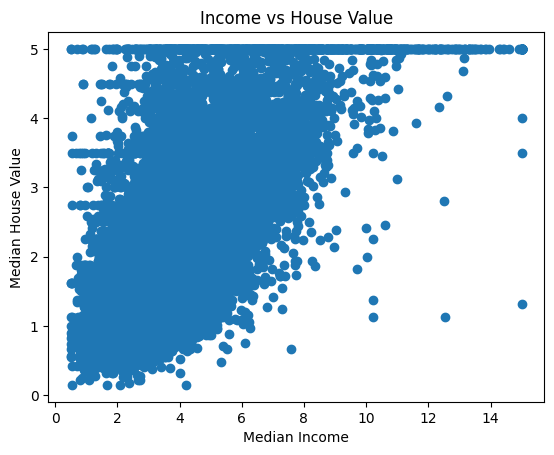

In [ ]:
plt.scatter(df['MedInc'], df['MedHouseVal'])
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Income vs House Value")
plt.show()

The scatter plot shows a strong positive relationship between median income and house value.

As income increases, house prices also tend to increase, confirming the strong correlation observed earlier. However, the points are widely scattered, suggesting that income alone does not fully determine house prices and that other factors also play a role.

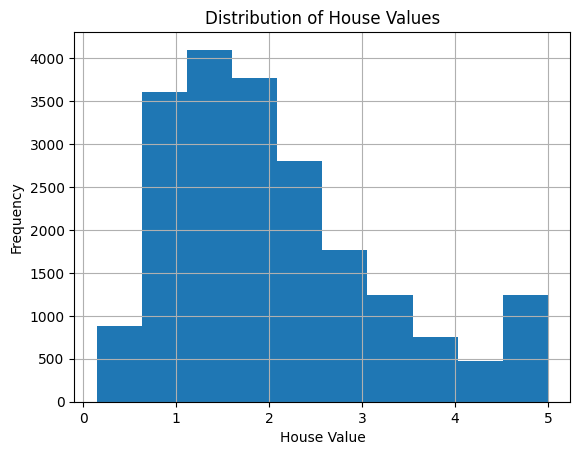

In [ ]:
df['MedHouseVal'].hist()
plt.title("Distribution of House Values")
plt.xlabel("House Value")
plt.ylabel("Frequency")
plt.show()

The histogram shows the distribution of house values.

Most houses fall within a certain price range, while fewer houses have very high values.

This indicates that the data is not evenly distributed and may be slightly skewed.

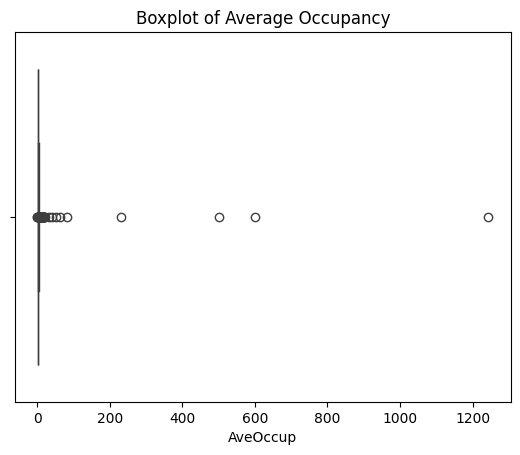

In [ ]:
sns.boxplot(x=df['AveOccup'])
plt.title("Boxplot of Average Occupancy")
plt.show()

The boxplot reveals the presence of extreme values (outliers) in the average occupancy variable.

These unusually high values may affect the performance of the regression model and should be considered during analysis.

In [ ]:
#Defining the x and y variables
X = df[['MedInc', 'AveRooms',  'HouseAge', 'Latitude','Longitude']]
y = df['MedHouseVal']

In [ ]:
#Importing and splitting the train and test variables
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

The dataset was split into training and testing sets to evaluate the model's performance on unseen data.

The training set is used to train the model, while the testing set is used to assess how well the model generalizes to new data.

This helps prevent overfitting, where the model performs well on training data but poorly on new data.

In [ ]:
#Training the model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
#Get the intercept and coefficients
print("Intercept:", model.intercept_)

coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coeff_df)

Intercept: -39.10264663401056
           Coefficient
MedInc        0.371180
AveRooms      0.019591
HouseAge      0.009801
Latitude     -0.459049
Longitude    -0.465865


The intercept represents the predicted house value when all predictor variables are zero.

The coefficient for median income (MedInc) is positive, meaning that as income increases, house prices also increase. Specifically, for each one-unit increase in median income, the house value increases by approximately 0.45 units, assuming other variables remain constant.

The coefficient for average rooms (AveRooms) is  positive, indicating that houses with more rooms tend to have higher values.

The coefficient for house age (HouseAge) is slightly positive, suggesting that older houses may have slightly higher values, although the effect is small.

The coefficient for latitude is negative, meaning that as we move north (higher latitude), house prices tend to decrease.

The coefficient for longitude is also negative, indicating that location plays an important role in house prices, with certain regions being less expensive than others.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.5432828320283413
RMSE: 0.7406555966702127


The model was evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

The MAE value of 0.543 indicates that, on average, the model’s predictions differ from the actual house values by approximately 0.5 units. Since the target variable is measured in hundreds of thousands of dollars, this corresponds to an average error of about $53,000.

The RMSE value of 0.741 is higher than the MAE, indicating that the model makes some larger errors, as RMSE penalizes larger deviations more heavily.

This shows that the model is  reasonably accurate. While it captures general trends in the data, the level of error suggests that predictions are not highly precise.



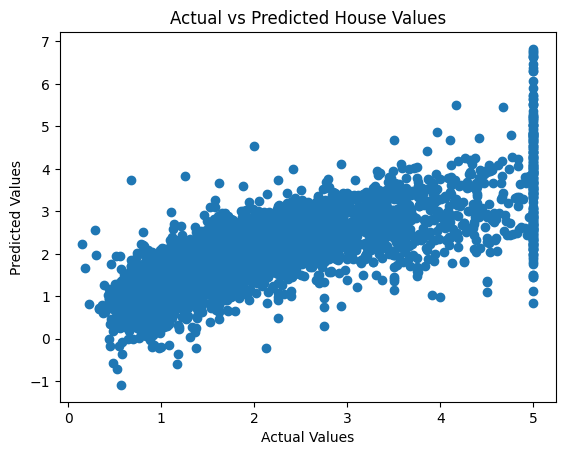

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Values")
plt.show()

The scatter plot of actual versus predicted values shows  a clear positive correlation indicating  that predictions follow the general trend, but there is noticeable spread, indicating prediction inaccuracies. It is less precise for extreme values, likely due to outliers.

# Reflections

1. I chose the California Housing dataset because it is well-suited for regression tasks and contains a variety of meaningful features such as income, housing characteristics, and geographic information. This made it useful for understanding how different factors influence house prices and for building an interpretable model.

2. I selected MedInc, AveRooms, HouseAge, Latitude, and Longitude as predictor variables based on correlation analysis. Median income showed the strongest relationship with house value, while the other variables provided additional information about housing structure and geographic location. These predictors were chosen to capture economic, physical, and spatial factors affecting house prices.

3. One of the most challenging parts of this assignment was understanding the evaluation metrics, especially the difference between MAE and RMSE, and how they reflect model performance. Interpreting the correlation heatmap was also difficult at first, particularly identifying meaningful relationships and recognizing multicollinearity between variables such as AveRooms and AveBedrms.

4. From this assignment, I learned how to build and evaluate a multiple linear regression model from start to finish. I now understand how to select predictors based on correlation, interpret regression coefficients, and evaluate model performance using MAE and RMSE.

I also learned that adding more variables does not always improve a model. Initially, including AveBedrms improved performance, but it introduced multicollinearity, making the model less interpretable. After removing it, the model became more stable and easier to interpret, even though there was a small trade-off in accuracy.

Overall, this assignment helped me understand the importance of balancing model performance, simplicity, and interpretability.